# Acompanhamento 1 - EDA e Estratégia de Limpeza

Este notebook faz parte do projeto de previsão de preços de imóveis com a base House Prices. O objetivo geral do projeto é entender quais características dos imóveis ajudam a explicar o valor de venda (`SalePrice`) e preparar uma estratégia consistente para um pipeline preditivo futuro.

Esta etapa corresponde ao **Acompanhamento 1**. O foco aqui é apresentar a Análise Exploratória de Dados (EDA) e uma estratégia inicial de limpeza dos dados. Não há implementação de modelo final, pipeline de produção ou alteração do arquivo `pipeline.py`.


## 1. Imports

Os imports ficam separados para deixar explícito quais bibliotecas são usadas nesta etapa exploratória.


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Configurações e caminhos

Os caminhos são relativos ao projeto. Assim, o notebook funciona tanto quando executado a partir da pasta `notebooks/` quanto a partir da raiz do projeto.


In [3]:
BASE_DIR = Path.cwd()
if BASE_DIR.name == "notebooks":
    PROJECT_DIR = BASE_DIR.parent
else:
    PROJECT_DIR = BASE_DIR

DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)

def salvar_figura(nome_arquivo):
    caminho = OUTPUT_DIR / nome_arquivo
    plt.tight_layout()
    plt.savefig(caminho, dpi=150, bbox_inches="tight")
    return caminho

print(f"Diretório do projeto: {PROJECT_DIR}")
print(f"Diretório dos dados: {DATA_DIR}")
print(f"Diretório de saídas: {OUTPUT_DIR}")


Diretório do projeto: c:\Users\braul\OneDrive\Documentos\GitHub\price_predict
Diretório dos dados: c:\Users\braul\OneDrive\Documentos\GitHub\price_predict\data
Diretório de saídas: c:\Users\braul\OneDrive\Documentos\GitHub\price_predict\outputs


## 3. Carregamento dos dados

Nesta etapa, carregamos o conjunto de treino e o conjunto de teste público. A variável alvo `SalePrice` deve existir apenas no treino, pois é ela que será prevista futuramente. A coluna `Id` identifica cada linha e não deve ser usada como variável preditiva.


In [4]:
treino = pd.read_csv(DATA_DIR / "treino.csv")
teste_publico = pd.read_csv(DATA_DIR / "teste_publico.csv")

resumo_carregamento = pd.DataFrame(
    {
        "dataset": ["treino", "teste_publico"],
        "linhas": [treino.shape[0], teste_publico.shape[0]],
        "colunas": [treino.shape[1], teste_publico.shape[1]],
        "possui_SalePrice": ["SalePrice" in treino.columns, "SalePrice" in teste_publico.columns],
        "possui_Id": ["Id" in treino.columns, "Id" in teste_publico.columns],
    }
)

display(resumo_carregamento)

print("SalePrice está apenas no treino:", "SalePrice" in treino.columns and "SalePrice" not in teste_publico.columns)
print("Id será tratado como identificador, não como feature preditiva.")


,dataset,linhas,colunas,possui_SalePrice,possui_Id
0,treino,1168,81,True,True
1,teste_publico,1459,80,False,True


SalePrice está apenas no treino: True
Id será tratado como identificador, não como feature preditiva.


## 4. Visão geral do dataset

A visão geral ajuda a entender o tamanho do problema, os tipos de variáveis e a escala dos principais atributos. Também separa variáveis numéricas e categóricas, o que será importante para a limpeza e para o pipeline futuro.


In [5]:
display(treino.head())

tipos = treino.dtypes.value_counts().rename_axis("tipo").reset_index(name="quantidade")
display(tipos)

colunas_numericas = treino.select_dtypes(include=np.number).columns.tolist()
colunas_categoricas = treino.select_dtypes(exclude=np.number).columns.tolist()

features_numericas = [col for col in colunas_numericas if col not in ["Id", "SalePrice"]]
features_categoricas = colunas_categoricas.copy()

print(f"Variáveis numéricas candidatas a feature: {len(features_numericas)}")
print(f"Variáveis categóricas candidatas a feature: {len(features_categoricas)}")
print(f"Primeiras numéricas: {features_numericas[:10]}")
print(f"Primeiras categóricas: {features_categoricas[:10]}")


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,255,20,RL,70.0,8400,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1957,1957,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,Gd,CBlock,TA,TA,No,Rec,922,Unf,0,392,1314,GasA,TA,Y,SBrkr,1314,0,0,1314,1,0,1,0,3,1,TA,5,Typ,0,NaN,Attchd,1957.0,RFn,1,294,TA,TA,Y,250,0,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal,145000
1,1067,60,RL,59.0,7837,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,7,1993,1994,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,Gd,TA,PConc,Gd,TA,No,Unf,0,Unf,0,799,799,GasA,Gd,Y,SBrkr,799,772,0,1571,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1993.0,RFn,2,380,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,5,2009,WD,Normal,178000
2,639,30,RL,67.0,8777,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Feedr,Norm,1Fam,1Story,5,7,1910,1950,Gable,CompShg,MetalSd,Wd Sdng,NaN,0.0,TA,TA,CBlock,Fa,TA,No,Unf,0,Unf,0,796,796,GasA,Gd,Y,FuseA,796,0,0,796,0,0,1,0,2,1,TA,4,Typ,0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,P,328,0,164,0,0,0,NaN,MnPrv,NaN,0,5,2008,WD,Normal,85000
3,800,50,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,SWISU,Feedr,Norm,1Fam,1.5Fin,5,7,1937,1950,Gable,CompShg,Wd Sdng,Wd Sdng,BrkFace,252.0,TA,TA,BrkTil,Gd,TA,No,ALQ,569,Unf,0,162,731,GasA,Ex,Y,SBrkr,981,787,0,1768,1,0,1,1,3,1,Gd,7,Typ,2,TA,Detchd,1939.0,Unf,1,240,TA,TA,Y,0,0,264,0,0,0,NaN,MnPrv,NaN,0,6,2007,WD,Normal,175000
4,381,50,RL,50.0,5000,Pave,Pave,Reg,Lvl,AllPub,Inside,Gtl,SWISU,Norm,Norm,1Fam,1.5Fin,5,6,1924,1950,Gable,CompShg,BrkFace,Wd Sdng,NaN,0.0,TA,TA,BrkTil,TA,TA,No,LwQ,218,Unf,0,808,1026,GasA,TA,Y,SBrkr,1026,665,0,1691,0,0,2,0,3,1,Gd,6,Typ,1,Gd,Detchd,1924.0,Unf,1,308,TA,TA,Y,0,0,242,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,127000


,tipo,quantidade
0,str,43
1,int64,35
2,float64,3


Variáveis numéricas candidatas a feature: 36
Variáveis categóricas candidatas a feature: 43
Primeiras numéricas: ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2']
Primeiras categóricas: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1']


In [6]:
estatisticas_numericas = treino[features_numericas + ["SalePrice"]].describe().T
estatisticas_numericas[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]].head(20)


,count,mean,std,min,25%,50%,75%,max
MSSubClass,1168.0,56.849315,42.531862,20.0,20.00,50.0,70.00,190.0
LotFrontage,951.0,70.343849,24.897021,21.0,59.00,70.0,80.00,313.0
LotArea,1168.0,10689.642123,10759.366198,1300.0,7587.25,9600.0,11700.00,215245.0
OverallQual,1168.0,6.121575,1.367619,1.0,5.00,6.0,7.00,10.0
OverallCond,1168.0,5.584760,1.116062,1.0,5.00,5.0,6.00,9.0
YearBuilt,1168.0,1970.965753,30.675495,1872.0,1953.00,1972.0,2001.00,2010.0
YearRemodAdd,1168.0,1984.897260,20.733955,1950.0,1966.00,1994.0,2004.00,2010.0
MasVnrArea,1162.0,103.771945,173.032238,0.0,0.00,0.0,166.00,1378.0
BsmtFinSF1,1168.0,446.023973,459.070977,0.0,0.00,384.5,721.00,5644.0
BsmtFinSF2,1168.0,45.152397,158.217499,0.0,0.00,0.0,0.00,1127.0


A base combina variáveis de área, qualidade, idade, localização e características específicas da casa. Como existem tipos diferentes de atributos, a limpeza precisará separar regras para variáveis numéricas, categóricas e identificadores.


## 5. Análise da variável alvo `SalePrice`

A distribuição de `SalePrice` mostra como os preços estão espalhados. Também analisamos `np.log1p(SalePrice)`, pois a métrica RMSLE compara erros em escala logarítmica e penaliza melhor erros relativos. No treino futuro, a transformação logarítmica pode estabilizar a distribuição; depois, as previsões devem voltar para dólares com `np.expm1`.


,SalePrice
count,1168.000000
mean,181441.541952
std,77263.583862
min,34900.000000
25%,130000.000000
50%,165000.000000
75%,214925.000000
max,745000.000000


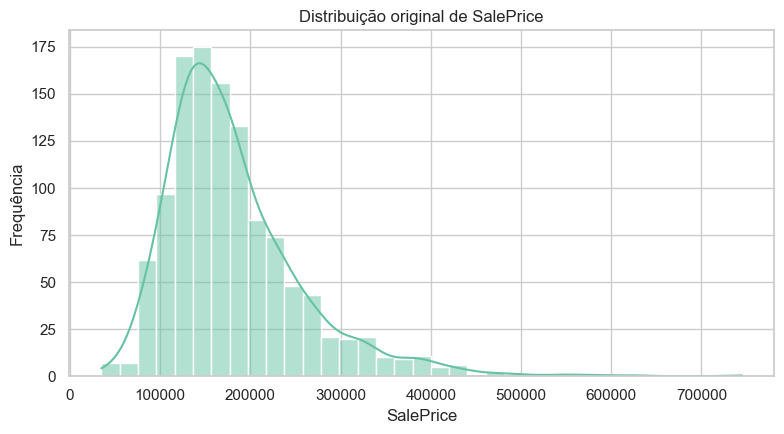

In [7]:
display(treino["SalePrice"].describe().to_frame())

plt.figure(figsize=(8, 4.5))
sns.histplot(treino["SalePrice"], kde=True, bins=35)
plt.title("Distribuição original de SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Frequência")
salvar_figura("saleprice_distribution.png")
plt.show()


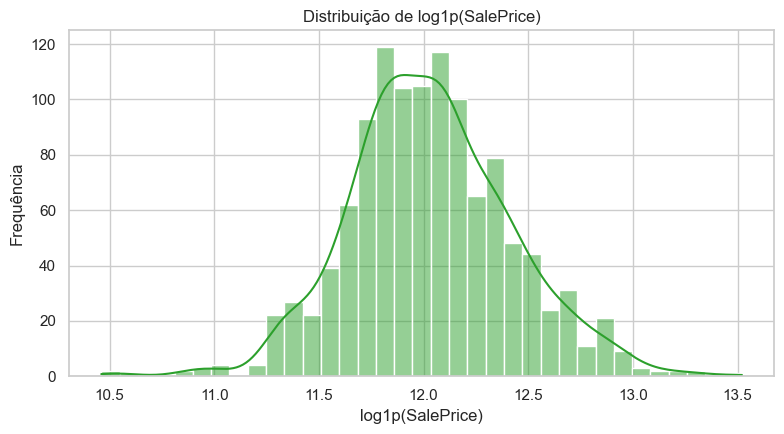

In [8]:
plt.figure(figsize=(8, 4.5))
sns.histplot(np.log1p(treino["SalePrice"]), kde=True, bins=35, color="tab:green")
plt.title("Distribuição de log1p(SalePrice)")
plt.xlabel("log1p(SalePrice)")
plt.ylabel("Frequência")
salvar_figura("saleprice_log_distribution.png")
plt.show()


A escala logarítmica reduz a assimetria da variável alvo e deixa casas de faixas de preço diferentes mais comparáveis em termos relativos. Essa decisão ainda será formalizada no pipeline do Acompanhamento 2.


## 6. Correlações principais

A correlação linear não explica tudo, mas é uma forma rápida de identificar variáveis numéricas associadas ao preço. A tabela abaixo mostra as 10 variáveis numéricas com maior correlação absoluta com `SalePrice`.


In [9]:
correlacoes = treino[colunas_numericas].corr(numeric_only=True)["SalePrice"].drop(labels=["SalePrice", "Id"], errors="ignore")
top_correlacoes = (
    correlacoes
    .to_frame("correlacao_com_SalePrice")
    .assign(correlacao_abs=lambda df: df["correlacao_com_SalePrice"].abs())
    .sort_values("correlacao_abs", ascending=False)
    .head(10)
)

display(top_correlacoes)


,correlacao_com_SalePrice,correlacao_abs
OverallQual,0.785555,0.785555
GrLivArea,0.695652,0.695652
GarageCars,0.640991,0.640991
GarageArea,0.624139,0.624139
TotalBsmtSF,0.597766,0.597766
1stFlrSF,0.587883,0.587883
FullBath,0.552546,0.552546
TotRmsAbvGrd,0.520388,0.520388
YearBuilt,0.516501,0.516501
YearRemodAdd,0.508593,0.508593


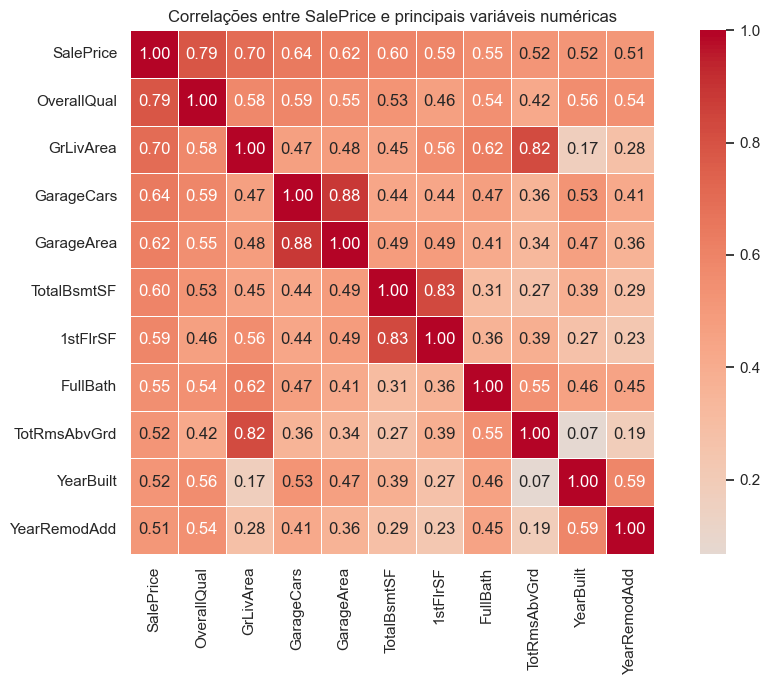

In [10]:
variaveis_heatmap = ["SalePrice"] + top_correlacoes.index.tolist()

plt.figure(figsize=(10, 7))
sns.heatmap(
    treino[variaveis_heatmap].corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
)
plt.title("Correlações entre SalePrice e principais variáveis numéricas")
salvar_figura("correlation_heatmap.png")
plt.show()


As variáveis de qualidade geral, área habitável, capacidade de garagem e área de porão tendem a aparecer entre as mais relacionadas ao preço. Isso sugere que o modelo futuro deve preservar bem atributos de qualidade, tamanho e infraestrutura da casa.


## 7. Variáveis categóricas relevantes

Algumas variáveis categóricas podem separar grupos de imóveis com medianas de preço bem diferentes. Para manter a EDA enxuta, analisamos apenas categorias relevantes quando elas existem no dataset.


In [11]:
categoricas_interesse = [
    "Neighborhood",
    "ExterQual",
    "KitchenQual",
    "BsmtQual",
    "GarageType",
    "SaleCondition",
    "MSZoning",
]

categoricas_existentes = [col for col in categoricas_interesse if col in treino.columns]
resumo_categoricas = []

for col in categoricas_existentes:
    resumo_categoricas.append(
        {
            "coluna": col,
            "categorias": treino[col].nunique(dropna=True),
            "nulos": int(treino[col].isna().sum()),
            "mediana_min": treino.groupby(col, dropna=False)["SalePrice"].median().min(),
            "mediana_max": treino.groupby(col, dropna=False)["SalePrice"].median().max(),
        }
    )

display(pd.DataFrame(resumo_categoricas))


,coluna,categorias,nulos,mediana_min,mediana_max
0,Neighborhood,25,0,89500.0,314813.0
1,ExterQual,4,0,85000.0,353459.5
2,KitchenQual,4,0,111750.0,319900.0
3,BsmtQual,4,28,99150.0,318000.0
4,GarageType,6,64,98950.0,223750.0
5,SaleCondition,6,0,104000.0,239399.5
6,MSZoning,5,0,96500.0,207500.0


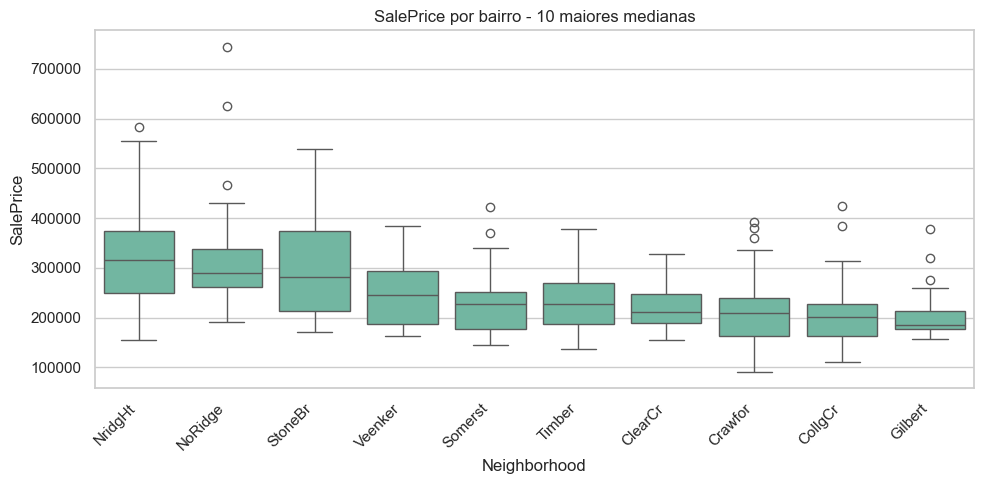

In [12]:
if "Neighborhood" in treino.columns:
    ordem_bairros = (
        treino.groupby("Neighborhood")["SalePrice"]
        .median()
        .sort_values(ascending=False)
        .head(10)
        .index
    )

    plt.figure(figsize=(10, 5))
    sns.boxplot(
        data=treino[treino["Neighborhood"].isin(ordem_bairros)],
        x="Neighborhood",
        y="SalePrice",
        order=ordem_bairros,
    )
    plt.title("SalePrice por bairro - 10 maiores medianas")
    plt.xlabel("Neighborhood")
    plt.ylabel("SalePrice")
    plt.xticks(rotation=45, ha="right")
    salvar_figura("neighborhood_saleprice.png")
    plt.show()
else:
    print("Coluna Neighborhood não encontrada.")


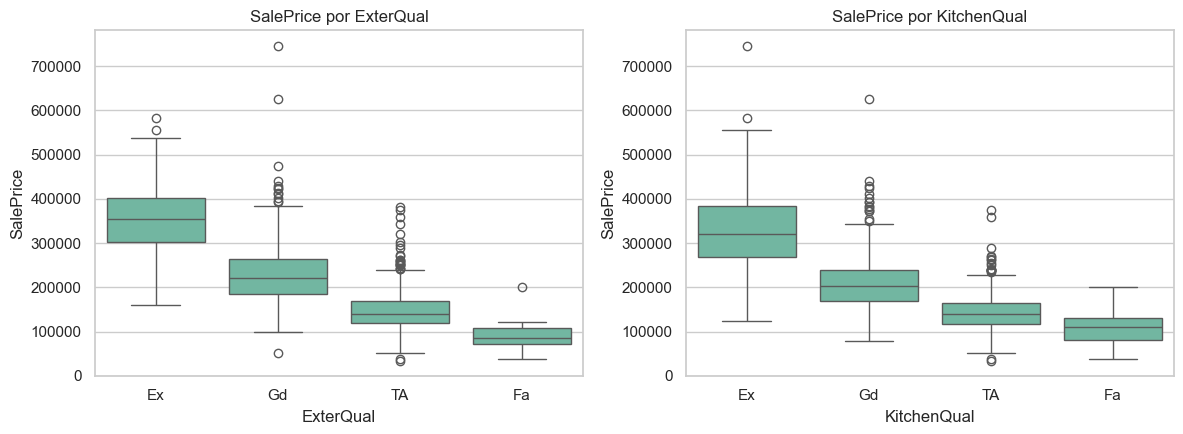

In [13]:
qualidade_cols = [col for col in ["ExterQual", "KitchenQual"] if col in treino.columns]

if qualidade_cols:
    fig, axes = plt.subplots(1, len(qualidade_cols), figsize=(6 * len(qualidade_cols), 4.5), squeeze=False)
    ordem_qualidade = ["Ex", "Gd", "TA", "Fa", "Po"]

    for ax, col in zip(axes.ravel(), qualidade_cols):
        ordem = [cat for cat in ordem_qualidade if cat in treino[col].dropna().unique()]
        sns.boxplot(data=treino, x=col, y="SalePrice", order=ordem, ax=ax)
        ax.set_title(f"SalePrice por {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("SalePrice")

    salvar_figura("quality_saleprice.png")
    plt.show()
else:
    print("Colunas de qualidade selecionadas não encontradas.")


As categorias mostram diferenças relevantes de preço, especialmente em localização (`Neighborhood`) e qualidade percebida (`ExterQual`, `KitchenQual`). Para o pipeline futuro, essas variáveis precisam ser codificadas de forma robusta, por exemplo, com `OneHotEncoder(handle_unknown="ignore")`.


## 8. Dados faltantes

Nesta etapa, identificamos quantidade, percentual e tipo de cada coluna com nulos. Em algumas variáveis do dicionário de dados, `NaN` possui significado real, como ausência de piscina, garagem, porão ou lareira. Por isso, nem todo nulo deve ser tratado como erro de preenchimento.


In [14]:
missing = treino.isna().sum()
tabela_nulos = (
    pd.DataFrame(
        {
            "coluna": missing.index,
            "qtd_nulos": missing.values,
            "perc_nulos": missing.values / len(treino) * 100,
            "tipo": treino.dtypes.astype(str).values,
        }
    )
    .query("qtd_nulos > 0")
    .sort_values(["perc_nulos", "qtd_nulos"], ascending=False)
)

def classificar_nulo(coluna):
    ausencia_recurso = {
        "PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
        "GarageType", "GarageFinish", "GarageQual", "GarageCond",
        "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
        "MasVnrType",
    }
    numericos_zero = {
        "GarageYrBlt", "GarageArea", "GarageCars", "BsmtFinSF1", "BsmtFinSF2",
        "BsmtUnfSF", "TotalBsmtSF", "BsmtFullBath", "BsmtHalfBath", "MasVnrArea",
    }
    if coluna in ausencia_recurso:
        return "a) nulo indica ausência do recurso"
    if coluna in numericos_zero:
        return "b) numérico pode virar 0"
    if pd.api.types.is_numeric_dtype(treino[coluna]):
        return "c) numérico sem significado claro"
    return "d) categórico pode virar Missing/None"

tabela_nulos["classificacao"] = tabela_nulos["coluna"].apply(classificar_nulo)
display(tabela_nulos)


,coluna,qtd_nulos,perc_nulos,tipo,classificacao
72,PoolQC,1162,99.486301,str,a) nulo indica ausência do recurso
74,MiscFeature,1122,96.061644,str,a) nulo indica ausência do recurso
6,Alley,1094,93.664384,str,a) nulo indica ausência do recurso
73,Fence,935,80.051370,str,a) nulo indica ausência do recurso
25,MasVnrType,683,58.476027,str,a) nulo indica ausência do recurso
57,FireplaceQu,547,46.832192,str,a) nulo indica ausência do recurso
3,LotFrontage,217,18.578767,float64,c) numérico sem significado claro
58,GarageType,64,5.479452,str,a) nulo indica ausência do recurso
59,GarageYrBlt,64,5.479452,float64,b) numérico pode virar 0
60,GarageFinish,64,5.479452,str,a) nulo indica ausência do recurso


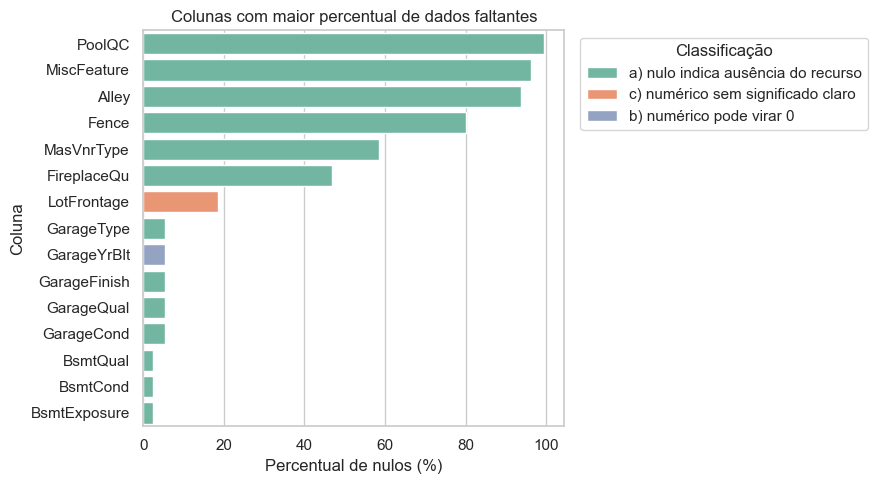

In [15]:
if not tabela_nulos.empty:
    plt.figure(figsize=(9, 5))
    sns.barplot(
        data=tabela_nulos.head(15),
        x="perc_nulos",
        y="coluna",
        hue="classificacao",
        dodge=False,
    )
    plt.title("Colunas com maior percentual de dados faltantes")
    plt.xlabel("Percentual de nulos (%)")
    plt.ylabel("Coluna")
    plt.legend(title="Classificação", bbox_to_anchor=(1.02, 1), loc="upper left")
    salvar_figura("missing_values.png")
    plt.show()
else:
    print("Não há valores nulos no treino.")


## 9. Estratégia de Limpeza dos Dados

A tabela abaixo resume a proposta de limpeza para ser formalizada no Acompanhamento 2. O ponto central é evitar vazamento de dados: medianas, modas e qualquer outra estatística de imputação devem ser calculadas apenas no treino e depois aplicadas ao teste.


In [16]:
estrategia_limpeza = pd.DataFrame(
    [
        ["Identificador", "Remover `Id` das features e guardar apenas como chave de submissão."],
        ["Categóricas de ausência", "Preencher variáveis como garagem, porão, piscina, cerca e lareira com 'None' quando NaN indicar ausência do recurso."],
        ["Numéricas de ausência", "Preencher áreas, contagens e banheiros associados a recursos ausentes com 0."],
        ["Numéricas sem significado claro", "Preencher nulos com mediana calculada no treino."],
        ["Categóricas sem significado claro", "Preencher com moda do treino ou com 'Missing', conforme a interpretação da coluna."],
        ["Variável alvo", "Usar `np.log1p(SalePrice)` durante o treino futuro para alinhar com RMSLE."],
        ["Retorno das previsões", "Usar `np.expm1` para converter previsões logarítmicas de volta para dólares."],
        ["Codificação categórica", "Usar `OneHotEncoder(handle_unknown='ignore')` futuramente para lidar com categorias novas no teste."],
        ["Data leakage", "Calcular imputações e codificações apenas no treino e reaplicar os parâmetros ao teste."],
    ],
    columns=["ponto", "proposta"],
)

display(estrategia_limpeza)


,ponto,proposta
0,Identificador,Remover `Id` das features e guardar apenas com...
1,Categóricas de ausência,"Preencher variáveis como garagem, porão, pisci..."
2,Numéricas de ausência,"Preencher áreas, contagens e banheiros associa..."
3,Numéricas sem significado claro,Preencher nulos com mediana calculada no treino.
4,Categóricas sem significado claro,"Preencher com moda do treino ou com 'Missing',..."
5,Variável alvo,Usar `np.log1p(SalePrice)` durante o treino fu...
6,Retorno das previsões,Usar `np.expm1` para converter previsões logar...
7,Codificação categórica,Usar `OneHotEncoder(handle_unknown='ignore')` ...
8,Data leakage,Calcular imputações e codificações apenas no t...


## 10. Limpeza Inicial Demonstrativa

A limpeza abaixo é feita em uma cópia do treino (`df_limpo`). Ela demonstra as decisões iniciais, mas não substitui o dataframe original usado na EDA. A versão definitiva deve ser implementada apenas no pipeline futuro do Acompanhamento 2.


In [17]:
df_limpo = treino.copy()
nulos_antes = int(df_limpo.isna().sum().sum())

if "Id" in df_limpo.columns:
    df_limpo = df_limpo.drop(columns="Id")

categoricas_ausencia = [
    "PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "MasVnrType",
]

numericas_ausencia_zero = [
    "GarageYrBlt", "GarageArea", "GarageCars",
    "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF",
    "BsmtFullBath", "BsmtHalfBath", "MasVnrArea",
]

categoricas_ausencia_existentes = [col for col in categoricas_ausencia if col in df_limpo.columns]
numericas_zero_existentes = [col for col in numericas_ausencia_zero if col in df_limpo.columns]

df_limpo[categoricas_ausencia_existentes] = df_limpo[categoricas_ausencia_existentes].fillna("None")
df_limpo[numericas_zero_existentes] = df_limpo[numericas_zero_existentes].fillna(0)

if "LotFrontage" in df_limpo.columns:
    df_limpo["LotFrontage"] = df_limpo["LotFrontage"].fillna(df_limpo["LotFrontage"].median())

numericas_com_nulos = df_limpo.select_dtypes(include=np.number).columns[df_limpo.select_dtypes(include=np.number).isna().any()].tolist()
for col in numericas_com_nulos:
    df_limpo[col] = df_limpo[col].fillna(df_limpo[col].median())

categoricas_com_nulos = df_limpo.select_dtypes(exclude=np.number).columns[df_limpo.select_dtypes(exclude=np.number).isna().any()].tolist()
for col in categoricas_com_nulos:
    df_limpo[col] = df_limpo[col].fillna("Missing")

nulos_depois = int(df_limpo.isna().sum().sum())

resumo_limpeza_demo = pd.DataFrame(
    {
        "momento": ["antes", "depois"],
        "total_de_nulos": [nulos_antes, nulos_depois],
        "colunas": [treino.shape[1], df_limpo.shape[1]],
    }
)

display(resumo_limpeza_demo)
print(f"Categóricas preenchidas como ausência: {categoricas_ausencia_existentes}")
print(f"Numéricas preenchidas com 0 por ausência: {numericas_zero_existentes}")


,momento,total_de_nulos,colunas
0,antes,6227,81
1,depois,0,80


Categóricas preenchidas como ausência: ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType']
Numéricas preenchidas com 0 por ausência: ['GarageYrBlt', 'GarageArea', 'GarageCars', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']


A cópia limpa remove o identificador das features e elimina nulos com regras coerentes com o dicionário de dados. Esta ainda é uma limpeza demonstrativa: no Acompanhamento 2, as mesmas decisões devem virar etapas reprodutíveis do pipeline, com parâmetros aprendidos somente no treino.


## 11. Outliers

A análise de outliers será simples nesta etapa. `GrLivArea` costuma ter relação forte com `SalePrice`, mas áreas muito extremas podem distorcer modelos. A remoção definitiva fica para a etapa de modelagem.


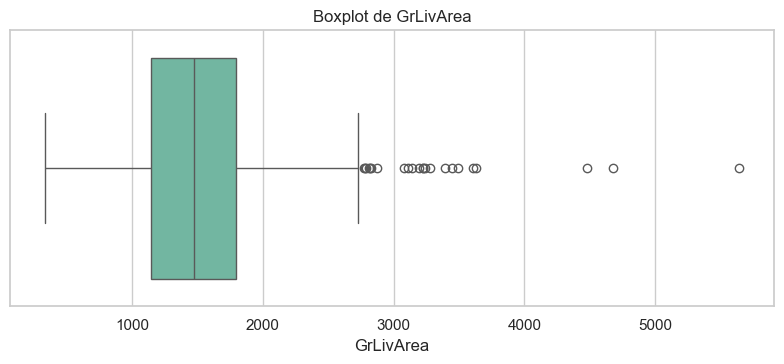

In [18]:
if "GrLivArea" in df_limpo.columns:
    plt.figure(figsize=(8, 3.8))
    sns.boxplot(data=df_limpo, x="GrLivArea")
    plt.title("Boxplot de GrLivArea")
    plt.xlabel("GrLivArea")
    salvar_figura("grlivarea_boxplot.png")
    plt.show()
else:
    print("Coluna GrLivArea não encontrada.")


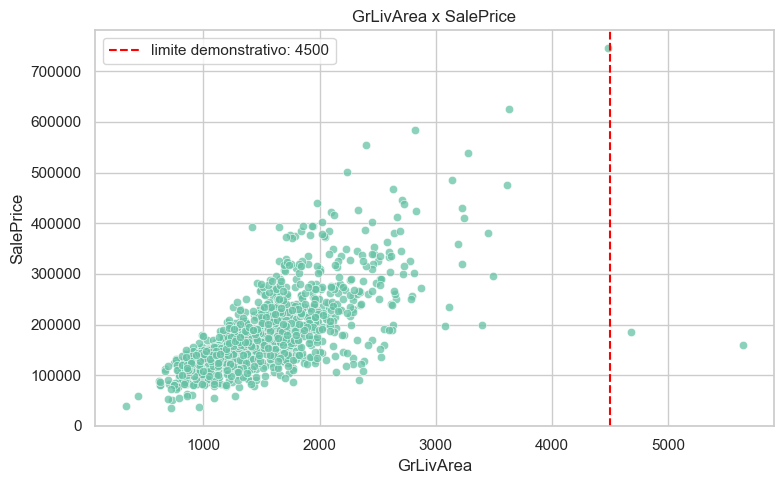

,GrLivArea,SalePrice
495,5642,160000
365,4676,184750


Linhas antes: 1168 | Linhas após filtro demonstrativo: 1166


In [19]:
if {"GrLivArea", "SalePrice"}.issubset(df_limpo.columns):
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df_limpo, x="GrLivArea", y="SalePrice", alpha=0.75)
    plt.axvline(4500, color="red", linestyle="--", label="limite demonstrativo: 4500")
    plt.title("GrLivArea x SalePrice")
    plt.xlabel("GrLivArea")
    plt.ylabel("SalePrice")
    plt.legend()
    salvar_figura("grlivarea_saleprice.png")
    plt.show()

    possiveis_extremos = df_limpo.loc[df_limpo["GrLivArea"] >= 4500, ["GrLivArea", "SalePrice"]].sort_values("GrLivArea", ascending=False)
    display(possiveis_extremos)

    df_sem_outliers = df_limpo[df_limpo["GrLivArea"] < 4500].copy()
    print(f"Linhas antes: {df_limpo.shape[0]} | Linhas após filtro demonstrativo: {df_sem_outliers.shape[0]}")
else:
    print("Colunas necessárias para o scatterplot não encontradas.")


Os pontos com `GrLivArea` muito alta são candidatos a investigação. O filtro `GrLivArea < 4500` foi mostrado apenas como demonstração em uma cópia, sem alterar a base original nem definir uma regra final para o projeto.


## 12. Conclusões do Acompanhamento 1

- A variável alvo `SalePrice` é assimétrica; `np.log1p(SalePrice)` é uma transformação promissora para o treino futuro por estar alinhada à RMSLE.
- As variáveis mais relevantes nesta EDA estão ligadas à qualidade, área habitável, garagem, porão e localização.
- Os principais problemas de dados são nulos com significados diferentes, especialmente em piscina, garagem, porão, lareira, cerca, revestimento e fachada do lote.
- A estratégia de limpeza definida separa nulos que indicam ausência de recurso, variáveis numéricas que podem virar 0, variáveis numéricas imputadas por mediana e variáveis categóricas preenchidas com `None` ou `Missing`.
- Para o Acompanhamento 2, os próximos passos são formalizar essas regras em um pipeline reprodutível, aplicar codificação categórica robusta e avaliar modelos sem vazamento de dados.
